<a href="https://colab.research.google.com/github/rengarajspt/sentiment-analysis/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install Packages**

In [57]:
!pip install nltk
!pip install tensorflow
!pip install streamlit
!pip install streamlit pyngrok

## **Import packages**

In [58]:
import pandas as pd
import numpy as np

import nltk
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer

## **Load dataset**

In [59]:
file="/content/chatgpt_style_reviews_dataset.xlsx"

df=pd.read_excel(file)
df

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No
...,...,...,...,...,...,...,...,...,...,...,...,...
495,2024-07-05 00:00:00,Review title 496,"Waste of time, does not meet expectations.",2,user496,81,7,Flipkart,ja,Qatar,1.2.3,No
496,########,Review title 497,"Great experience, smooth performance and usefu...",5,user497,48,7,Google Play,fr,Nepal,2.1.4,No
497,########,Review title 498,"Terrible experience, needs major improvements.",2,user498,16,5,Google Play,de,Poland,2.1.4,Yes
498,########,Review title 499,"Highly satisfied, the app works exactly as exp...",4,user499,68,8,Google Play,zh,Nepal,1.2.3,Yes


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               500 non-null    object
 1   title              500 non-null    object
 2   review             500 non-null    object
 3   rating             500 non-null    int64 
 4   username           500 non-null    object
 5   helpful_votes      500 non-null    int64 
 6   review_length      500 non-null    int64 
 7   platform           500 non-null    object
 8   language           500 non-null    object
 9   location           500 non-null    object
 10  version            500 non-null    object
 11  verified_purchase  500 non-null    object
dtypes: int64(3), object(9)
memory usage: 47.0+ KB


In [61]:
df.describe()

,rating,helpful_votes,review_length
count,500.000000,500.000000,500.000000
mean,3.012000,103.090000,6.934000
std,1.366598,57.747896,1.453916
min,1.000000,0.000000,5.000000
25%,2.000000,55.750000,6.000000
50%,3.000000,104.500000,7.000000
75%,4.000000,152.000000,8.000000
max,5.000000,200.000000,10.000000


In [62]:
df.shape

(500, 12)

In [63]:
df.isnull().sum()

,0
date,0
title,0
review,0
rating,0
username,0
helpful_votes,0
review_length,0
platform,0
language,0
location,0


# **EDA**

In [64]:
df["date"].value_counts()

,count
date,
########,358
2024-03-07 00:00:00,4
2024-03-02 00:00:00,4
2025-02-01 00:00:00,4
2024-02-03 00:00:00,4
...,...
2024-07-07 00:00:00,1
2024-03-03 00:00:00,1
2025-03-06 00:00:00,1


In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df.dtypes

,0
date,object
title,object
review,object
rating,int64
username,object
helpful_votes,int64
review_length,int64
platform,object
language,object
location,object


In [67]:
df['review'].head()

,review
0,"Not satisfied, many bugs and issues."
1,Amazing quality and user-friendly interface.
2,"Terrible experience, needs major improvements."
3,Poor performance and not user-friendly.
4,"Not satisfied, many bugs and issues."


## **Find target**

In [68]:
def get_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["sentiment"] = df["rating"].apply(get_sentiment)
df["sentiment"].value_counts()

,count
sentiment,
Positive,200
Negative,195
Neutral,105


In [69]:
df['sentiment']

,sentiment
0,Negative
1,Positive
2,Negative
3,Negative
4,Negative
...,...
495,Negative
496,Positive
497,Negative
498,Positive


In [70]:
for i in df.columns:
  print(display(df[i].value_counts()))

,count
date,
########,358
2024-03-07 00:00:00,4
2024-03-02 00:00:00,4
2025-02-01 00:00:00,4
2024-02-03 00:00:00,4
...,...
2024-07-07 00:00:00,1
2024-03-03 00:00:00,1
2025-03-06 00:00:00,1


None


,count
title,
Review title 500,1
Review title 1,1
Review title 2,1
Review title 3,1
Review title 484,1
...,...
Review title 9,1
Review title 8,1
Review title 7,1


None


,count
review,
"Highly satisfied, the app works exactly as expected.",50
"Waste of time, does not meet expectations.",43
Very reliable and worth using regularly.,43
Poor performance and not user-friendly.,41
"Terrible experience, needs major improvements.",41
"Great experience, smooth performance and useful features.",39
"Very disappointing experience, the app crashes often.",38
"Excellent app, very easy to use and extremely helpful.",35
Amazing quality and user-friendly interface.,33


...

None


,count
verified_purchase,
No,262
Yes,238


None


,count
sentiment,
Positive,200
Negative,195
Neutral,105


None


In [71]:
num_cols = df.select_dtypes(include='number').columns

cat_cols = df.select_dtypes(include='object').columns

print(num_cols,"\n","\n", cat_cols)

Index(['rating', 'helpful_votes', 'review_length'], dtype='object') 
 
 Index(['date', 'title', 'review', 'username', 'platform', 'language',
       'location', 'version', 'verified_purchase', 'sentiment'],
      dtype='object')


## **Univerate analysis**

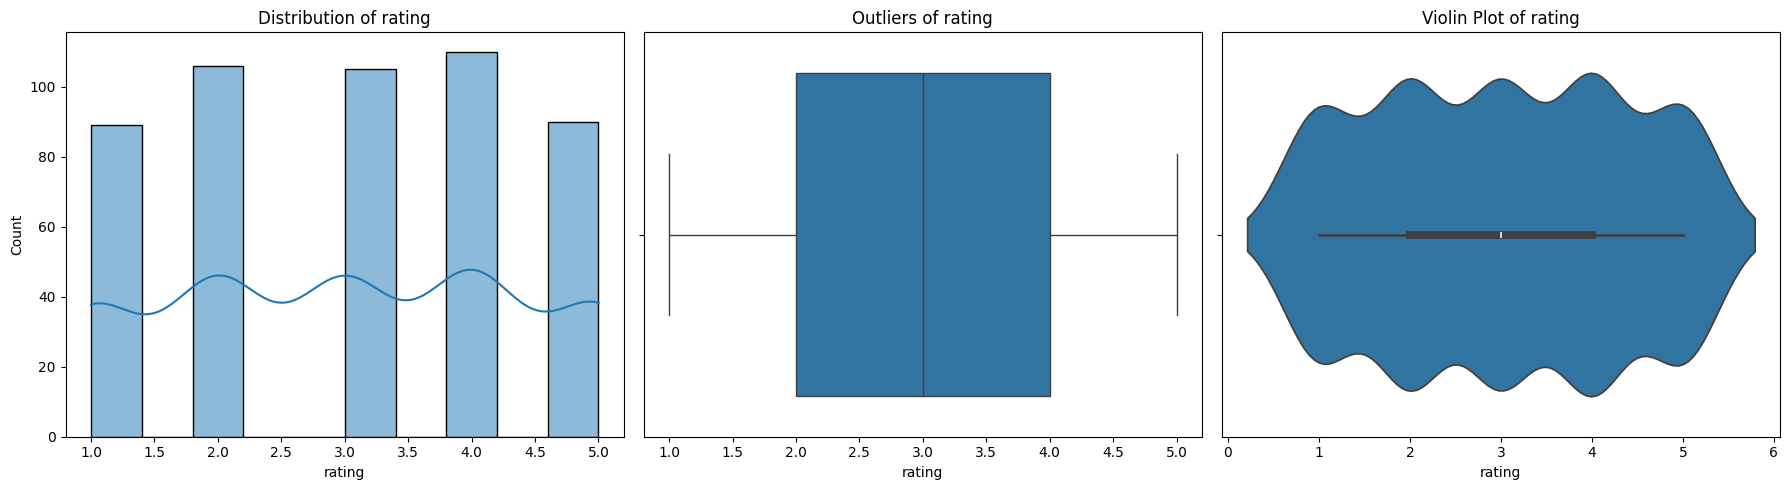

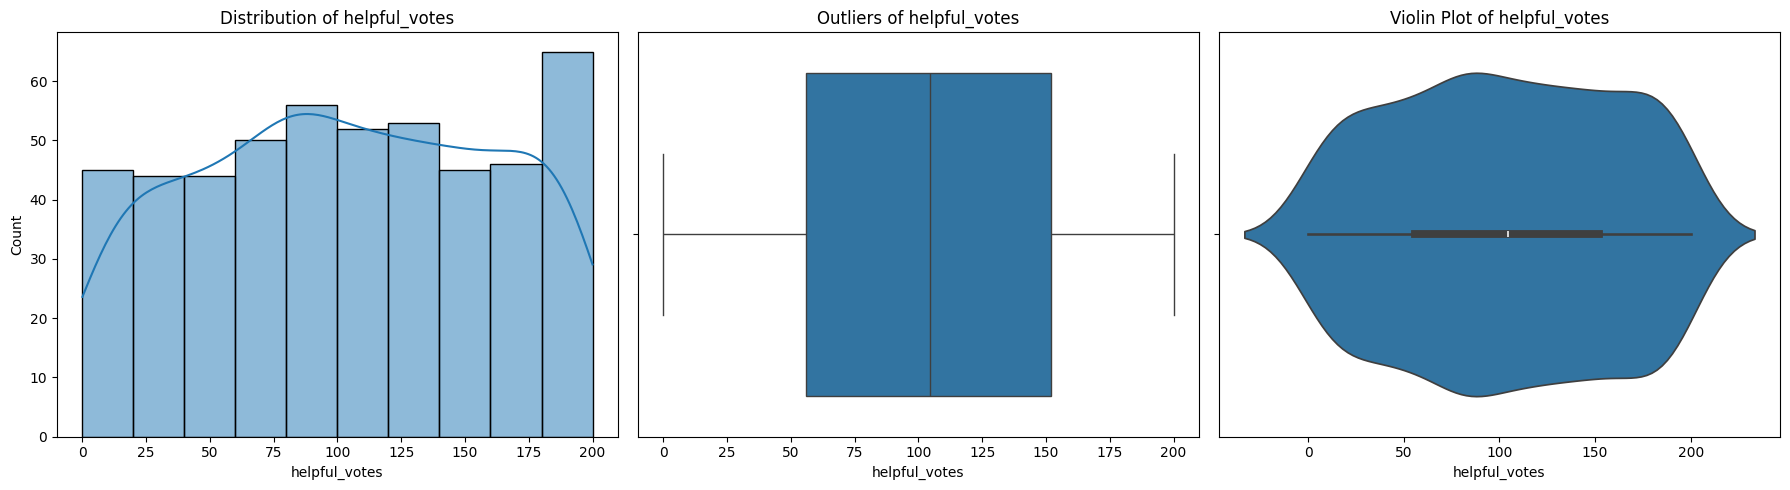

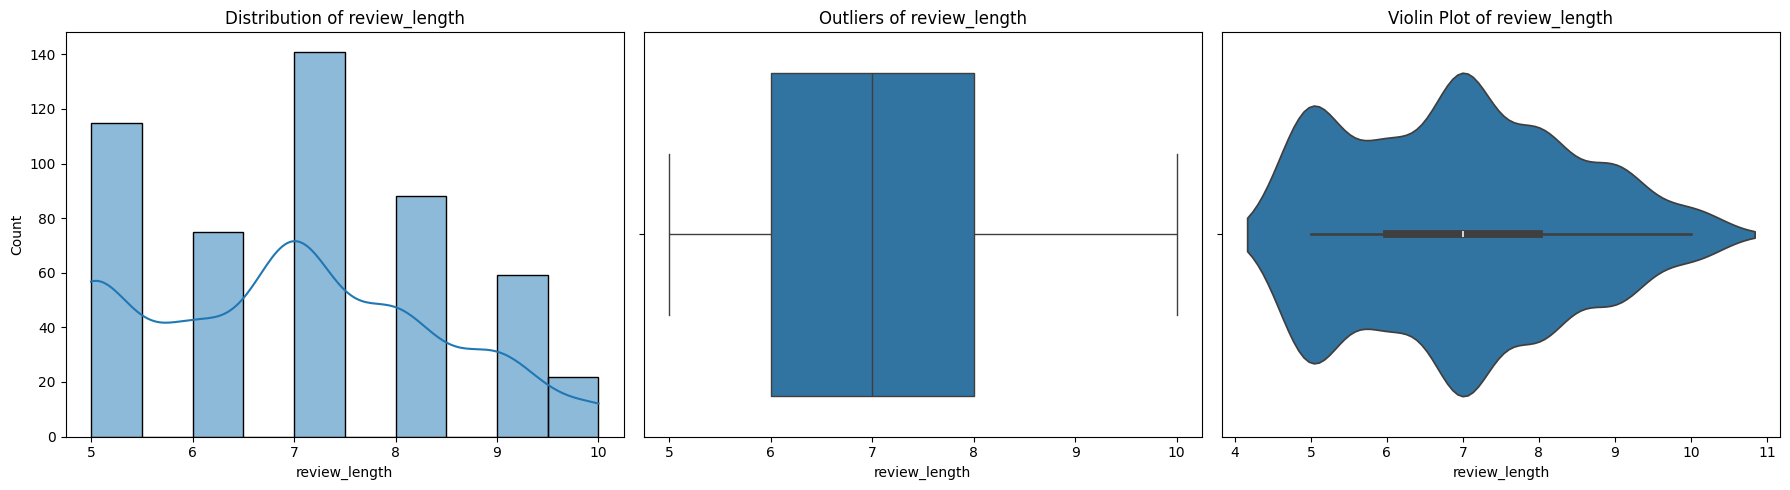

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

for col in num_cols:

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1️⃣ Histogram
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")

    # 2️⃣ Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Outliers of {col}")

    # 3️⃣ Violin plot
    sns.violinplot(x=df[col], ax=axes[2])
    axes[2].set_title(f"Violin Plot of {col}")

    plt.tight_layout()
    plt.show()

## **Bivariate Analysis**

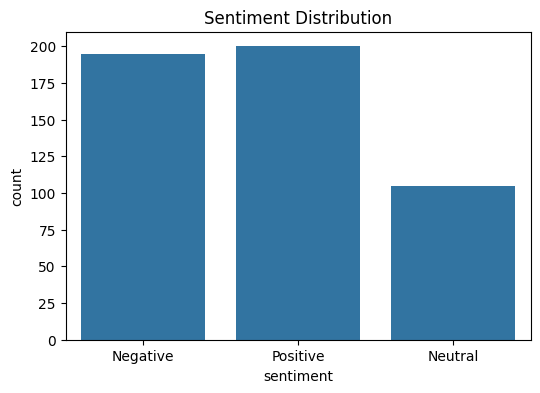

In [73]:
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()

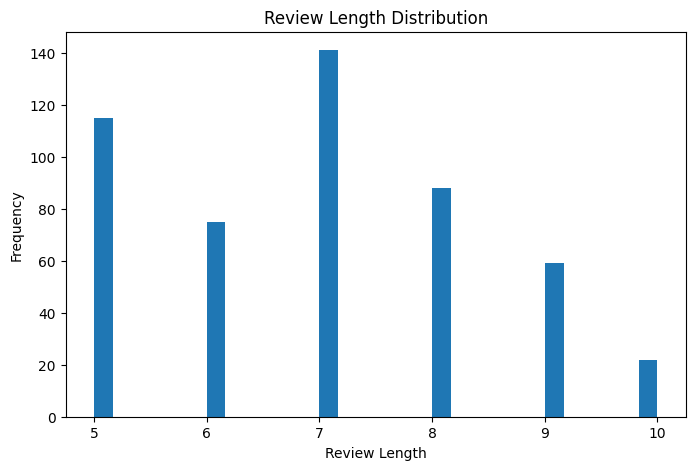

In [74]:
plt.figure(figsize=(8,5))
plt.hist(df["review_length"], bins=30)
plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.show()

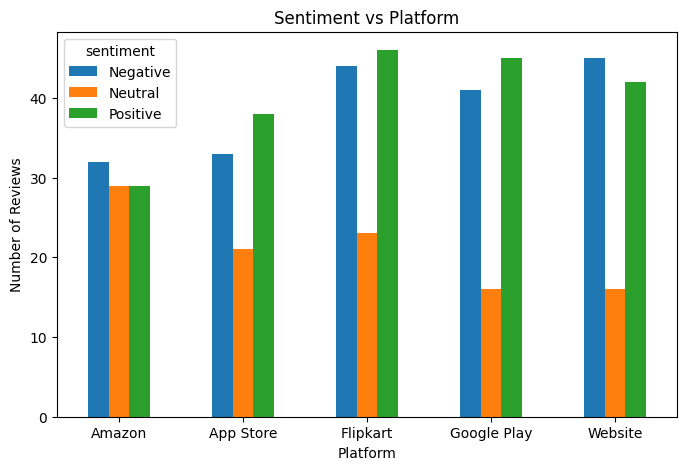

In [75]:
platform_sentiment = pd.crosstab(df["platform"], df["sentiment"])
platform_sentiment.plot(kind="bar", figsize=(8,5))

plt.title("Sentiment vs Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

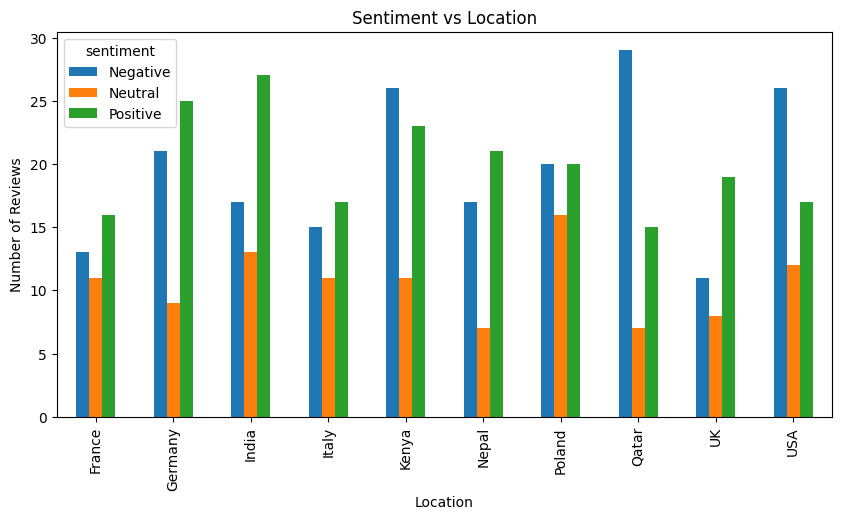

In [76]:
location_sentiment = pd.crosstab(df["location"], df["sentiment"])
location_sentiment.plot(kind="bar", figsize=(10,5))

plt.title("Sentiment vs Location")
plt.xlabel("Location")
plt.ylabel("Number of Reviews")

plt.show()

## **Multivariate analysis**

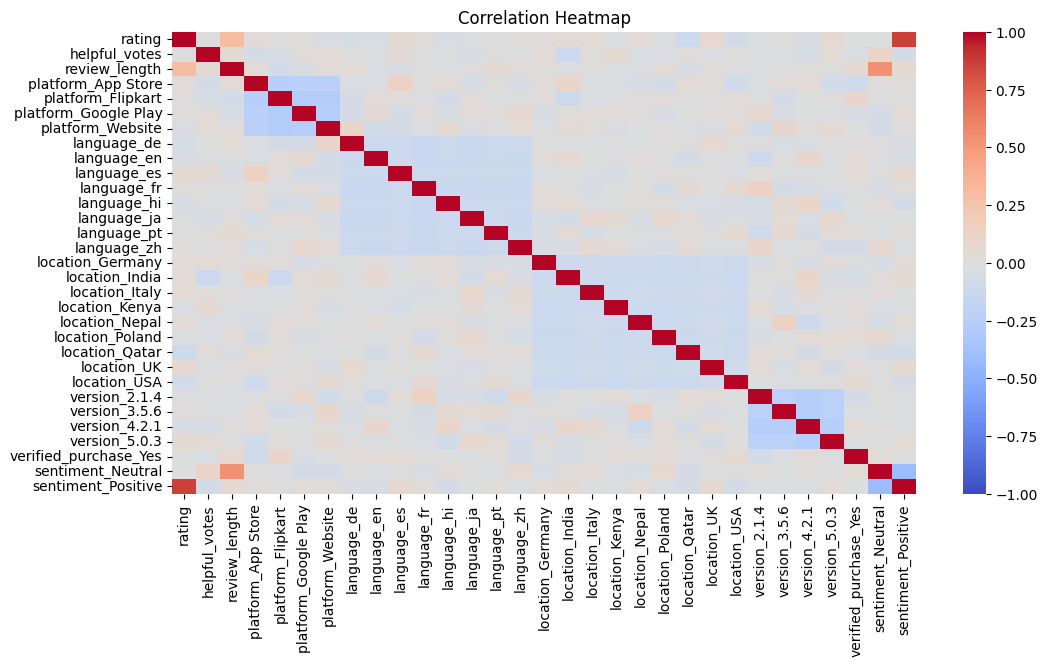

In [77]:
df_encoded = pd.get_dummies(df[[
    'rating',
    'helpful_votes',
    'review_length',
    'platform',
    'language',
    'location',
    'version',
    'verified_purchase',
    'sentiment'
]], drop_first=True)

corr_matrix = df_encoded.corr()

plt.figure(figsize=(12,6))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Correlation Heatmap")
plt.show()

# **Projects_visuals**

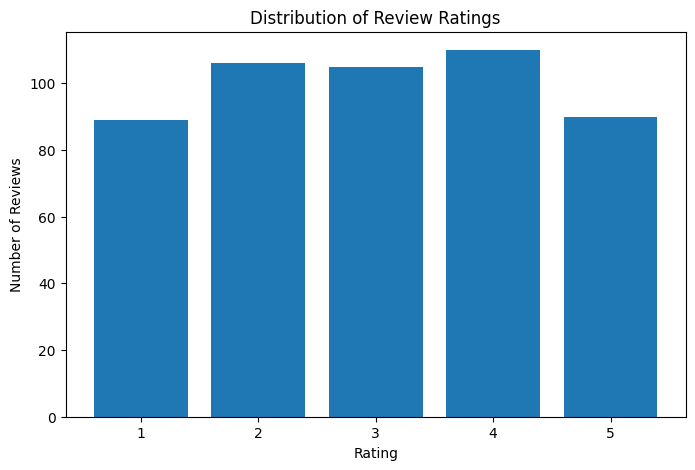

In [78]:
plt.figure(figsize=(8,5))

rating_counts = df['rating'].value_counts().sort_index()

plt.bar(rating_counts.index, rating_counts.values)

plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.xticks([1,2,3,4,5])

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128078 (\N{THUMBS DOWN SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


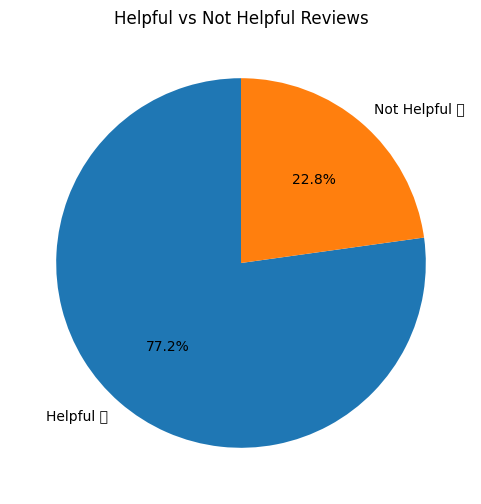

In [79]:
threshold = 50

help_cat = df['helpful_votes'].apply(
    lambda x: 'Helpful 👍' if x > threshold else 'Not Helpful 👎'
)


helpful_counts = help_cat.value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    helpful_counts,
    labels=helpful_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Helpful vs Not Helpful Reviews")

plt.show()

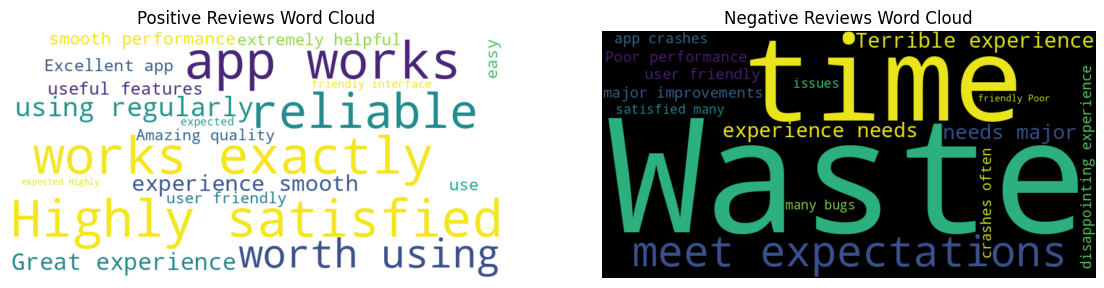

In [80]:
positive_reviews = df[df['rating'] >= 4]['review']
negative_reviews = df[df['rating'] <= 2]['review']

positive_text = " ".join(positive_reviews)
negative_text = " ".join(negative_reviews)

positive_wc = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

negative_wc = WordCloud(width=800, height=400, background_color='black').generate(negative_text)

plt.figure(figsize=(14,6))

# Positive Word Cloud
plt.subplot(1,2,1)
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Reviews Word Cloud")

# Negative Word Cloud
plt.subplot(1,2,2)
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Reviews Word Cloud")

plt.show()

/tmp/ipykernel_709/4140381594.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['date'] = pd.to_datetime(df1['date'], errors='coerce')


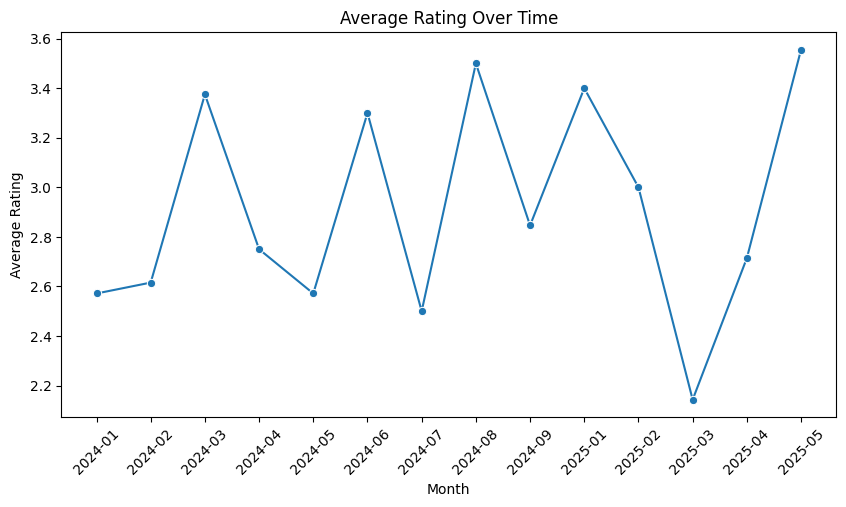

In [81]:
df1=df.copy()

df1['date'] = pd.to_datetime(df1['date'], errors='coerce')

df1 = df1.dropna(subset=['date'])

df1['month'] = df1['date'].dt.to_period('M')

avg_rating = df1.groupby('month')['rating'].mean().reset_index()

avg_rating['month'] = avg_rating['month'].astype(str)

plt.figure(figsize=(10,5))

sns.lineplot(data=avg_rating, x='month', y='rating', marker='o')

plt.title("Average Rating Over Time")
plt.xlabel("Month")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

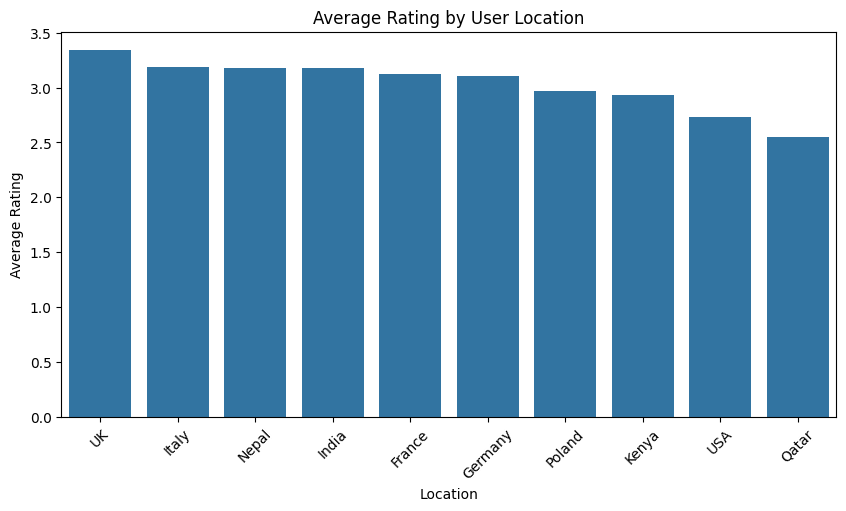

In [82]:
location_rating = df.groupby('location')['rating'].mean().reset_index()
location_rating = location_rating.sort_values(by='rating', ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(data=location_rating, x='location', y='rating')

plt.title("Average Rating by User Location")
plt.xlabel("Location")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

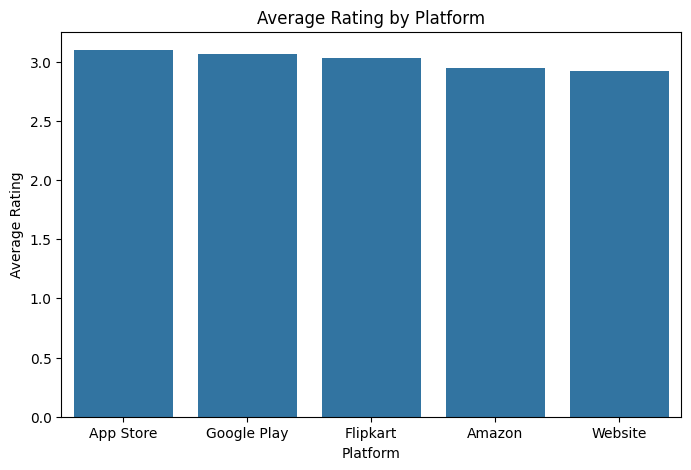

In [83]:
platform_rating = df.groupby('platform')['rating'].mean().reset_index()
platform_rating = platform_rating.sort_values(by='rating', ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(data=platform_rating, x='platform', y='rating')

plt.title("Average Rating by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Rating")

plt.show()

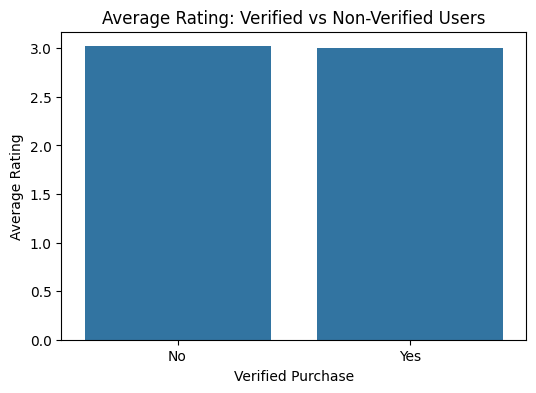

In [84]:
verified_rating = df.groupby('verified_purchase')['rating'].mean().reset_index()
plt.figure(figsize=(6,4))

sns.barplot(data=verified_rating, x='verified_purchase', y='rating')

plt.title("Average Rating: Verified vs Non-Verified Users")
plt.xlabel("Verified Purchase")
plt.ylabel("Average Rating")

plt.show()

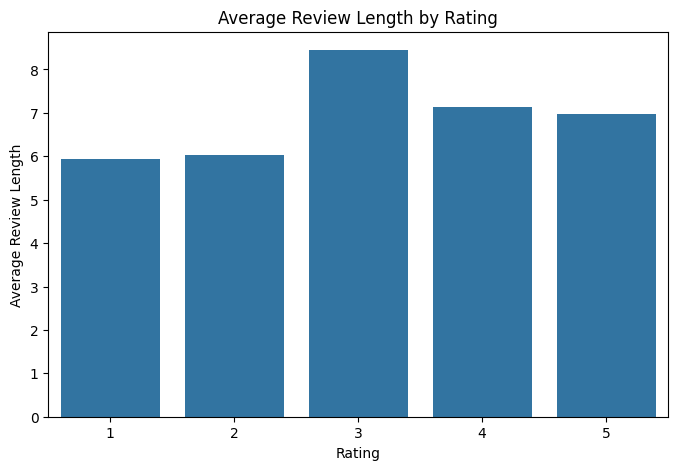

In [85]:
avg_length = df.groupby('rating')['review_length'].mean().reset_index()
plt.figure(figsize=(8,5))

sns.barplot(data=avg_length, x='rating', y='review_length')

plt.title("Average Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Review Length")

plt.show()

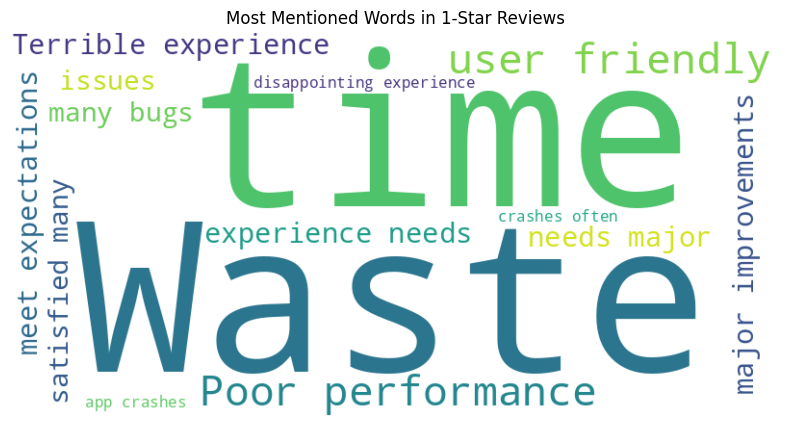

In [86]:
one_star_reviews = df[df['rating'] == 1]['review']
text_1star = " ".join(one_star_reviews)

wc = WordCloud(width=800, height=400, background_color='white').generate(text_1star)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Most Mentioned Words in 1-Star Reviews")

plt.show()

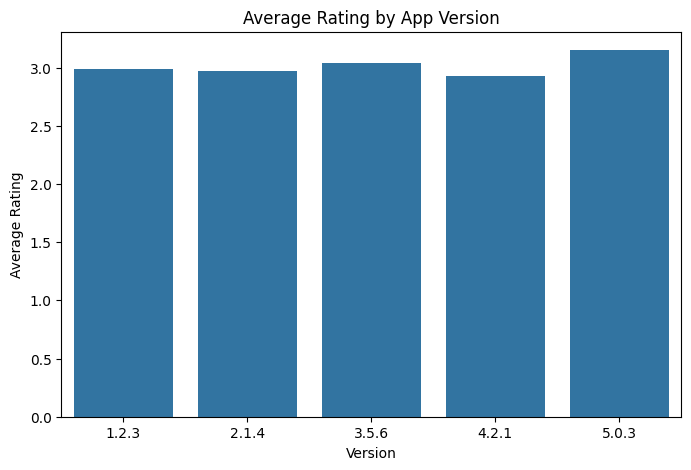

In [87]:
version_rating = df.groupby('version')['rating'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(data=version_rating, x='version', y='rating')

plt.title("Average Rating by App Version")
plt.xlabel("Version")
plt.ylabel("Average Rating")

plt.show()

# **Preprocessing**

In [88]:
df = df.drop(['date','username','title'], axis=1)

df.to_pickle("reviews_data.pkl")   # save dataframe to streamlit visuals

df.head()

,review,rating,helpful_votes,review_length,platform,language,location,version,verified_purchase,sentiment
0,"Not satisfied, many bugs and issues.",1,80,6,Amazon,zh,Kenya,2.1.4,No,Negative
1,Amazing quality and user-friendly interface.,5,180,5,Flipkart,zh,France,1.2.3,No,Positive
2,"Terrible experience, needs major improvements.",2,154,5,Flipkart,pt,USA,1.2.3,No,Negative
3,Poor performance and not user-friendly.,1,96,5,Amazon,es,Qatar,2.1.4,Yes,Negative
4,"Not satisfied, many bugs and issues.",2,139,6,Website,ar,Kenya,2.1.4,No,Negative


In [89]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources (run once)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def preprocess_review(text):

    # Step 1: Convert text to lowercase
    text = text.lower()

    # Step 2: Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Step 3: Tokenize text into individual words
    tokens = word_tokenize(text)

    # Step 4: Remove stopwords (common words like 'the', 'is', 'and')
    tokens = [word for word in tokens if word not in stop_words]

    # Step 5: Lemmatization (convert words to base form)
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Step 6: Join tokens back into a sentence
    cleaned_text = " ".join(tokens)

    return cleaned_text

df["clean_review"] = df["review"].apply(preprocess_review)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [90]:
from sklearn import preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack


tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_text = tfidf.fit_transform(df['clean_review'])

X_num = df[['rating']].values

X = hstack([X_text, X_num])

sentiment_map = {
    "Negative": 0,
    "Neutral" : 1,
    "Positive": 2
}


df["sentiment"] = df["sentiment"].map(sentiment_map)
y = df.loc[:,'sentiment']

In [91]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42,  )


## **Model Training**

In [92]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

In [93]:
y_pred_nb

array([1, 2, 2, 2, 1, 1, 2, 1, 2, 0, 2, 1, 0, 2, 1, 0, 0, 1, 2, 2, 0, 1,
       2, 1, 1, 0, 0, 1, 0, 2, 1, 0, 1, 0, 0, 2, 1, 2, 0, 2, 0, 0, 1, 0,
       1, 2, 0, 1, 0, 2, 1, 2, 1, 0, 2, 2, 0, 2, 0, 2, 2, 1, 2, 0, 0, 2,
       0, 2, 0, 0, 0, 2, 2, 2, 0, 2, 0, 2, 0, 0, 0, 2, 2, 0, 2, 0, 2, 2,
       2, 2, 2, 1, 1, 0, 0, 1, 1, 2, 1, 0])

In [94]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [95]:
y_pred_lr

array([1, 2, 2, 2, 1, 1, 2, 1, 2, 0, 2, 1, 0, 2, 1, 0, 0, 1, 2, 2, 0, 1,
       2, 1, 1, 0, 0, 1, 0, 2, 1, 0, 1, 0, 0, 2, 1, 2, 0, 2, 0, 0, 1, 0,
       1, 2, 0, 1, 0, 2, 1, 2, 1, 0, 2, 2, 0, 2, 0, 2, 2, 1, 2, 0, 0, 2,
       0, 2, 0, 0, 0, 2, 2, 2, 0, 2, 0, 2, 0, 0, 0, 2, 2, 0, 2, 0, 2, 2,
       2, 2, 2, 1, 1, 0, 0, 1, 1, 2, 1, 0])

In [96]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [97]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [98]:
max_words = 10000
max_len = 200

num_classes = len(np.unique(y))

lstm_mdl = Sequential()
lstm_mdl.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
lstm_mdl.add(LSTM(64))
lstm_mdl.add(Dropout(0.5))
lstm_mdl.add(Dense(num_classes, activation='softmax'))  # multi-class

lstm_mdl.compile(
    loss='sparse_categorical_crossentropy',  # integer labels
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [99]:
history = lstm_mdl.fit(
    X_train, y_train,
    epochs=10,
    batch_size=2,
    validation_split=0.2
)


Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.6206 - loss: 0.9506 - val_accuracy: 1.0000 - val_loss: 0.0573
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 1.0000 - loss: 0.0416 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 5.9474e-04
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 3.4164e-04
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 2.2603e-04
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 1.0000 - loss: 8.3803e-04 - val_accuracy: 1.0000 - val_loss: 1.7541e-04
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 1.0000 - 

In [100]:
loss, acc = lstm_mdl.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.3f}")



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 7.8603e-05 
Test Accuracy: 1.000


In [101]:
y_pred_ls  = lstm_mdl.predict(X_test)
y_pred_lstm = np.argmax(y_pred_ls, axis=1)
y_pred_lstm

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


array([1, 2, 2, 2, 1, 1, 2, 1, 2, 0, 2, 1, 0, 2, 1, 0, 0, 1, 2, 2, 0, 1,
       2, 1, 1, 0, 0, 1, 0, 2, 1, 0, 1, 0, 0, 2, 1, 2, 0, 2, 0, 0, 1, 0,
       1, 2, 0, 1, 0, 2, 1, 2, 1, 0, 2, 2, 0, 2, 0, 2, 2, 1, 2, 0, 0, 2,
       0, 2, 0, 0, 0, 2, 2, 2, 0, 2, 0, 2, 0, 0, 0, 2, 2, 0, 2, 0, 2, 2,
       2, 2, 2, 1, 1, 0, 0, 1, 1, 2, 1, 0])

## **Model Testing**

In [102]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

predictions = {
    "Naive Bayes": y_pred_nb,
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Lstm" : y_pred_lstm,
}

models = {
    "Naive Bayes": nb_model,
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Lstm" : lstm_mdl,
}

def evaluate_model(y_true, y_pred):
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))


for model_name, y_pred in predictions.items():
  # if model_name not in 'Lstm':
    print(f"\n{'='*40}")
    print(model_name.upper())
    print(f"{'='*40}")

    evaluate_model(y_test, y_pred)





NAIVE BAYES

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        39

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


Confusion Matrix:
 [[36  0  0]
 [ 0 25  0]
 [ 0  0 39]]

LOGISTIC REGRESSION

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        39

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


Confusion Matrix:
 [[36  0  0]
 [ 0 25  0]
 [ 0  0 39]]

RANDOM FOREST

Classification Report:
 

In [103]:
results =[]

for model_name, y_pred in predictions.items():

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })


results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,1.0,1.0,1.0,1.0
1,Logistic Regression,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0
3,Lstm,1.0,1.0,1.0,1.0


In [104]:
results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,1.0,1.0,1.0,1.0
1,Logistic Regression,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0
3,Lstm,1.0,1.0,1.0,1.0


In [105]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns


NAIVE BAYES
AUC ROC Score: 1.0


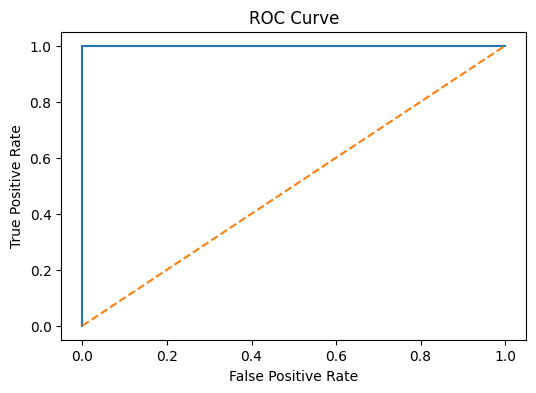


LOGISTIC REGRESSION
AUC ROC Score: 1.0


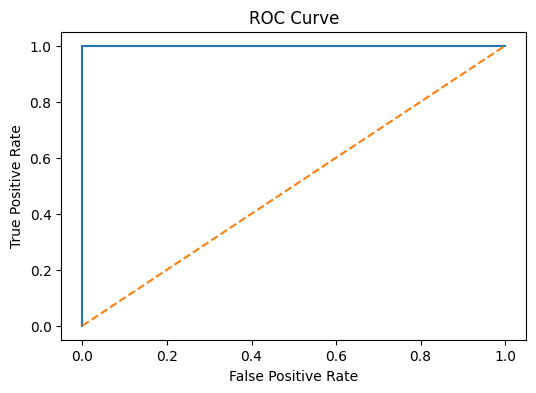


RANDOM FOREST
AUC ROC Score: 1.0


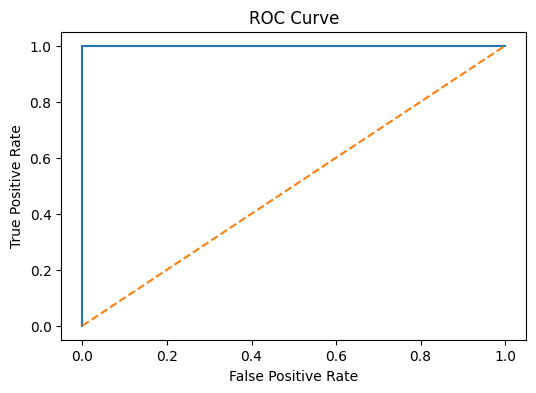


LSTM
AUC ROC Score: 1.0


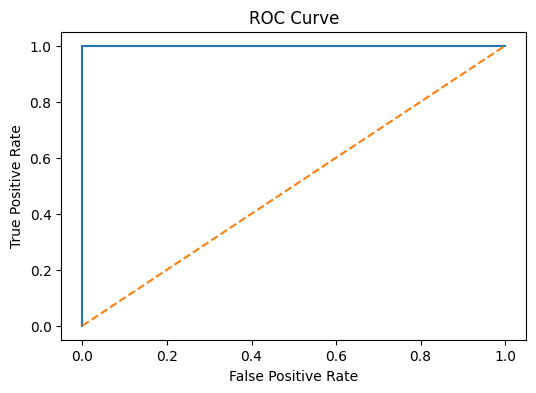

In [106]:
for model_name, y_pred in predictions.items():
    print(f"\n{'='*40}")
    print(model_name.upper())
    print(f"{'='*40}")

    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)
    if model_name =="Lstm":
      auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr")
      print("AUC ROC Score:", auc)

      fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
      plt.figure(figsize=(6,4))
      plt.plot(fpr, tpr)
      plt.plot([0,1],[0,1],'--')

      plt.title("ROC Curve")
      plt.xlabel("False Positive Rate")
      plt.ylabel("True Positive Rate")
      plt.show()


    elif model_name not in 'Lstm':
      model = models[model_name]

      y_prob = model .predict_proba(X_test)
      auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr")
      print("AUC ROC Score:", auc)

      fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
      plt.figure(figsize=(6,4))
      plt.plot(fpr, tpr)
      plt.plot([0,1],[0,1],'--')

      plt.title("ROC Curve")
      plt.xlabel("False Positive Rate")
      plt.ylabel("True Positive Rate")
      plt.show()

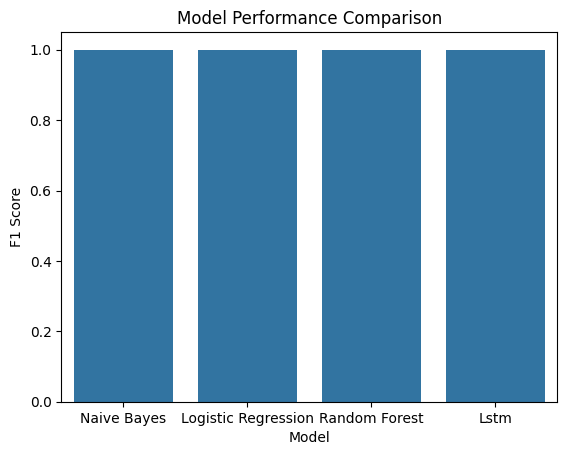

In [107]:
sns.barplot(x="Model", y="F1 Score", data=results_df)
plt.title("Model Performance Comparison")
plt.show()

## **Save Models**

In [108]:
import joblib

best_model_name = results_df.tail(1).iloc[0]["Model"]

best_model = models[best_model_name]

file_name = 'best_model.pkl'

joblib.dump(best_model, file_name)

print(f"Best model '{best_model_name}' saved successfully!")

Best model 'Lstm' saved successfully!


In [109]:

file_path = 'vector.pkl'

joblib.dump(tfidf,vector)

print(f"Best model '{best_model_name}' saved successfully!")

Best model 'Lstm' saved successfully!


# **Streamlit app.py**

In [110]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
from scipy.sparse import hstack
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import re
import numpy as np


# load artifacts
file_name = 'best_model.pkl'
file_path = 'vector.pkl'

model = joblib.load(file_name)
tfidf = joblib.load(file_path)

st.markdown("""
<style>

/* App background */
.stApp {
    background-color: #f8f6f2;
}

/* Main title */
.main-title {
    color: #8b1c2e;
    font-size: 50px;
    font-weight: 700;
    text-align: center;
    letter-spacing: 2px;
}

/* Subtitle */
.sub-title {
    color: #8b1c2e;
    font-size: 60px;
    font-weight: 900;
    text-align: center;
    letter-spacing: 4px;
    margin-top: 20px;
}

/* Sidebar background */
section[data-testid="stSidebar"] {
    background-color: #ffffff;
}

/* Predict button */
.stButton>button {
    background-color: #8b1c2e;
    color: white;
    font-size: 18px;
    border-radius: 8px;
    padding: 10px 25px;
}

.stButton>button:hover {
    background-color: #6f1423;
}

/* Result card */
.result-card {
    background-color: white;
    padding: 30px;
    border-radius: 10px;
    border-left: 8px solid #8b1c2e;
    text-align: center;
    font-size: 70px;
    font-weight: bold;
}

</style>
""", unsafe_allow_html=True)

# ------------------------------------------------------------------------------------------------------------------------------------------------------

st.set_page_config(page_title="Review App", layout="centered")

# Navigation
page = st.sidebar.selectbox(
    "Navigate",
    ["Review Page", "Review Analysis"]
)

# ------------------------------------------------------------------------------------------------------------------------------------------------------

if page == "Review Page":

  st.markdown('<div class="sub-title">Customer Review</div>', unsafe_allow_html=True)
  st.markdown(""" <h1 style='text-align: center;color:#2E86C1;'>Feedback is the compass for greatness</h3> """, unsafe_allow_html=True)

  star_options = ["⭐", "⭐⭐", "⭐⭐⭐", "⭐⭐⭐⭐", "⭐⭐⭐⭐⭐"]
  rating = st.radio("How would you like the app", options=star_options, index=3, horizontal=True)

  rating_value = star_options.index(rating) + 1         # Convert stars to numeric rating

  review = st.text_area(
    'Customer review ',
    placeholder="We truly value your opinion",
    height=150 )

  input_df = pd.DataFrame({
        "rating":[rating_value],
        "review":[review]
    })

  X_text = tfidf.transform(input_df["review"])         # TFIDF transform


  X_num = input_df[["rating"]].values           # numeric feature


  X = hstack([X_text, X_num])              # combine features

  pred_ls = model.predict(X)

  pred = np.argmax(pred_ls, axis=1)[0]

  reverse_map = {0:"Negative", 1:"Neutral", 2:"Positive"}

  sentiment = reverse_map[pred]

  if len(rating) == 5 :
        stars = "⭐⭐⭐⭐⭐"
  elif len(rating) == 4 :
        stars = "⭐⭐⭐⭐☆"
  elif len(rating) == 3:
        stars = "⭐⭐⭐☆☆"
  elif len(rating) == 2:
        stars = "⭐⭐☆☆☆"
  else:
        stars = "⭐☆☆☆☆"

  submit = st.button("Submit")

  if submit:
    if review.strip() == "":
        st.warning("Please enter a review.")
    else:
        st.markdown(
            f"""
             <div style="
              background:white;
             padding:30px;
              border-radius:15px;
             text-align:center;
             box-shadow:0 4px 12px rgba(0,0,0,0.2);
             font-family:sans-serif;
              ">

            <h2 style='color:#4CAF50;'>Thank You For Your Feedback!</h2>

            <h1 style='color:#f59e0b'>{stars}</h1>

           <p style='font-style:italic; color:#333;'>“{review}”</p>

           <p style="color:#386E1F; font-weight:bold; font-size:28px;">{sentiment}</p>

          </div>
           """, unsafe_allow_html=True )




# -------------------------------------------------------------------------------------------------------------------------------------------------------

df = pd.read_pickle("reviews_data.pkl")

#  -------------------------------------------------------------------------------------------------------------------------------------------------------
if page == "Review Analysis":
  st.markdown('<div class="sub-title">Review Data Analysis</div>', unsafe_allow_html=True)

  analysis_option = st.selectbox(
    "Select Analysis",
    [
        "Overall Sentiment",
        "Sentiment vs Rating",
        "Keywords by Sentiment",
        "Sentiment vs Helpful Votes",
        "Verified vs Non Verified Users",
        "Review Length vs Sentiment",
        "Sentiment by Location",
        "Sentiment by Platform",
        "Sentiment by Version",
        "Negative Feedback Themes"
    ]
)

# -------- KEYWORD FUNCTION --------
  def get_keywords(texts):
    words = []
    for t in texts:
        w = re.findall(r'\b[a-z]+\b', str(t).lower())
        words.extend(w)
    return Counter(words).most_common(10)

# -------- VISUALS --------

  if analysis_option == "Overall Sentiment":

    st.subheader("Overall Sentiment Distribution")

    sentiment_counts = df["sentiment"].value_counts()

    fig, ax = plt.subplots()
    sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, ax=ax)
    ax.set_ylabel("Count")
    st.pyplot(fig)


  elif analysis_option == "Sentiment vs Rating":

    st.subheader("Sentiment vs Rating")

    fig, ax = plt.subplots()
    sns.countplot(data=df, x="rating", hue="sentiment", ax=ax)
    st.pyplot(fig)


  elif analysis_option == "Keywords by Sentiment":

    st.subheader("Keywords Associated With Sentiment")

    sentiment_type = st.selectbox("Select Sentiment", df["sentiment"].unique())

    keywords = get_keywords(df[df["sentiment"] == sentiment_type]["review"])

    kw_df = pd.DataFrame(keywords, columns=["Word","Frequency"])

    fig, ax = plt.subplots()
    sns.barplot(data=kw_df, x="Frequency", y="Word", ax=ax)
    st.pyplot(fig)


  elif analysis_option == "Sentiment vs Helpful Votes":

    st.subheader("Sentiment vs Helpful Votes")

    fig, ax = plt.subplots()
    sns.boxplot(data=df, x="sentiment", y="helpful_votes", ax=ax)
    st.pyplot(fig)


  elif analysis_option == "Verified vs Non Verified Users":

    st.subheader("Verified vs Non Verified Sentiment")

    fig, ax = plt.subplots()
    sns.countplot(data=df, x="verified_purchase", hue="sentiment", ax=ax)
    st.pyplot(fig)


  elif analysis_option == "Review Length vs Sentiment":

    st.subheader("Review Length vs Sentiment")

    fig, ax = plt.subplots()
    sns.boxplot(data=df, x="sentiment", y="review_length", ax=ax)
    st.pyplot(fig)


  elif analysis_option == "Sentiment by Location":

    st.subheader("Sentiment by Location")

    location_df = df.groupby(["location","sentiment"]).size().unstack().fillna(0)

    fig, ax = plt.subplots(figsize=(8,5))
    location_df.plot(kind="bar", ax=ax)
    st.pyplot(fig)


  elif analysis_option == "Sentiment by Platform":

    st.subheader("Sentiment by Platform")

    fig, ax = plt.subplots()
    sns.countplot(data=df, x="platform", hue="sentiment", ax=ax)
    st.pyplot(fig)


  elif analysis_option == "Sentiment by Version":

    st.subheader("Sentiment by Version")

    fig, ax = plt.subplots()
    sns.countplot(data=df, x="version", hue="sentiment", ax=ax)
    st.pyplot(fig)


  elif analysis_option == "Negative Feedback Themes":

    st.subheader("Common Negative Feedback Words")

    negative_words = get_keywords(df[df["sentiment"]=="Negative"]["review"])
    neg_df = pd.DataFrame(negative_words, columns=["Word","Frequency"])

    fig, ax = plt.subplots()
    sns.barplot(data=neg_df, x="Frequency", y="Word", ax=ax)
    st.pyplot(fig)



Writing app.py


## **Externel link**

In [111]:
!ngrok config add-authtoken 2yR73U8kGQt6Rlz3McOfC3aSVwO_6GBQpX1VgcsBBLMnuAZY3

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [112]:
!streamlit run app.py &>/dev/null &

In [113]:
from pyngrok import ngrok

ngrok.kill()

if not ngrok.get_tunnels():
    public_url = ngrok.connect(8501)
    print(public_url)

NgrokTunnel: "https://43b0-136-119-105-47.ngrok-free.app" -> "http://localhost:8501"
